In [9]:
# hier ein Beispielcode, in dem per Simulation verschiedene Methoden der Konfidenzintervallschätzung am Beispiel
# der Erwartungswertschaetzung verdeutlicht werden

import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt

# Einstellungen
np.random.seed(45)
true_mean = 0
true_std = 1
n = 30               # Stichprobengröße
n_sim = 1000         # Anzahl Wiederholungen
n_boot = 300        # Anzahl Bootstrap-Wiederholungen
alpha = 0.05         # Signifikanzniveau (z.B. 95% KI)

# Speichert Anzahl der erfolgreichen Überdeckungen
coverage = {
    "Bootstrap Percentil": 0,
    "Bootstrap Varianz": 0,
    "Theoretisch": 0
}

# Hauptschleife über viele Stichproben
for _ in range(n_sim):
    sample = np.random.normal(loc=true_mean, scale=true_std, size=n)
    sample_mean = np.mean(sample)

    # --- Bootstrap Verfahren ---
    boot_means = []
    for _ in range(n_boot):
        resample = np.random.choice(sample, size=n, replace=True)
        boot_means.append(np.mean(resample))
    boot_means = np.array(boot_means)

    # Percentil-Methode
    lower_pct = np.percentile(boot_means, 100 * alpha / 2)
    upper_pct = np.percentile(boot_means, 100 * (1 - alpha / 2))

    if lower_pct <= true_mean <= upper_pct:
        coverage["Bootstrap Percentil"] += 1

    # Varianz-Methode (Normalapproximation)
    boot_std = np.std(boot_means, ddof=1)
    z_score = norm.ppf(1 - alpha / 2)
    lower_var = sample_mean - z_score * boot_std
    upper_var = sample_mean + z_score * boot_std

    if lower_var <= true_mean <= upper_var:
        coverage["Bootstrap Varianz"] += 1

    # Theoretisches Intervall mit geschätzter Standardabweichung
    sample_std = np.std(sample, ddof=1)
    se = sample_std / np.sqrt(n)
    lower_theo = sample_mean - z_score * se
    upper_theo = sample_mean + z_score * se

    if lower_theo <= true_mean <= upper_theo:
        coverage["Theoretisch"] += 1

# Umrechnung in Anteile
results = pd.DataFrame({
    "Methode": list(coverage.keys()),
    "Überdeckungswahrscheinlichkeit": [v / n_sim for v in coverage.values()]
})

# Ergebnisse anzeigen
display(results)


,Methode,Überdeckungswahrscheinlichkeit
0,Bootstrap Percentil,0.921
1,Bootstrap Varianz,0.932
2,Theoretisch,0.935


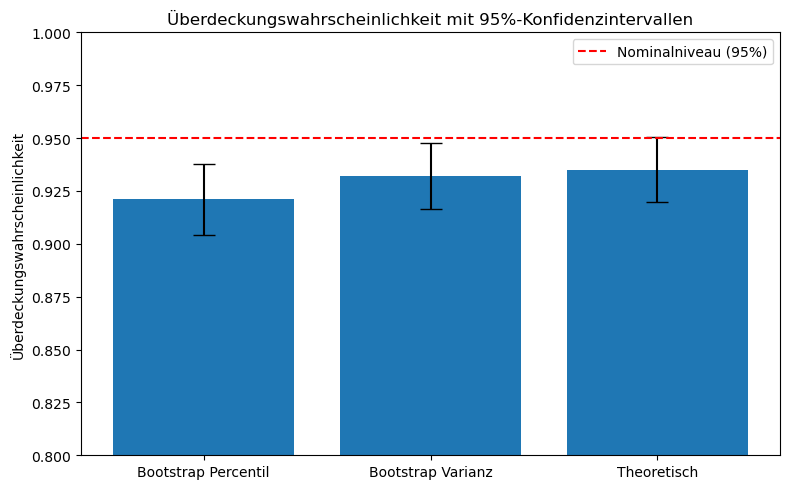

In [10]:
import matplotlib.pyplot as plt
from scipy.stats import norm

# Z-Wert für Konfidenzintervall (z.B. 95%)
z_score = norm.ppf(1 - alpha / 2)

# Konfidenzintervalle berechnen
p_hat = results["Überdeckungswahrscheinlichkeit"]
n_trials = n_sim
se = np.sqrt(p_hat * (1 - p_hat) / n_trials)
ci_lower = p_hat - z_score * se
ci_upper = p_hat + z_score * se

# Plot mit Fehlerbalken
plt.figure(figsize=(8, 5))
plt.bar(results["Methode"], p_hat, yerr=z_score * se, capsize=8)
plt.axhline(1 - alpha, color='red', linestyle='--', label='Nominalniveau (95%)')
plt.title('Überdeckungswahrscheinlichkeit mit 95%-Konfidenzintervallen')
plt.ylabel('Überdeckungswahrscheinlichkeit')
plt.ylim(0.8, 1.0)
plt.legend()
plt.tight_layout()
plt.show()
